# Анализ сервиса доставки еды: поиск инсайтов и точек роста

Сервис доставки готовой еды успешно функционирует уже более года: ему удалось отстроиться от конкурентов и привлечь постоянных пользователей, однако на данном этапе руководство ждёт от продукта роста. Задача - найти инсайты, которые позволят сервису повысить показатель удержания пользователей и улучшить взаимодействие с партнёрами.

Необходимо помочь бизнесу ответить на следующие вопросы:
- Как ведут себя пользователи? Как наиболее эффективно выстроить работу с ними, чтобы они продолжали пользоваться продуктом?
- Какой путь проходят пользователи в сервисе? Где «проваливаются»?
- Как улучшить взаимодействие с партнёрами-ресторанами?

### Задачи 

- Изучить пользовательский путь и проанализировать конверсии через воронки;
- Сегментировать пользователей с помощью RFM-модели для оценки лояльности и поведения клиентов;
- Кластеризовать рестораны методом K-Means, чтобы выделить группы с разными моделями работы и разработать персонализированные маркетинговые стратегии.
    
### План проекта
- Загрузка данных и их предобработка.
- Анализ пользовательского пути новых пользователей.
- RFM сегментация.
- K-Means кластеризация.
- Итоговый вывод и рекомендации.

## 1. Загрузка данных и их предобработка

In [1]:
# Загрузим библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
# Загрузим датасет, сразу приведем столбцы с датой и временем к типу datetime
df = pd.read_csv('https://code.s3.yandex.net/datasets/insides_data.csv', parse_dates=['first_date', 'datetime'])

In [3]:
# Ознакомимся с датасетом
display(df.info())
display(df.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205510 entries, 0 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   visitor_uuid  205510 non-null  object        
 1   user_id       205510 non-null  float64       
 2   device_type   205510 non-null  object        
 3   city_id       205510 non-null  int64         
 4   source        205510 non-null  object        
 5   first_date    205510 non-null  datetime64[ns]
 6   visit_id      205510 non-null  int64         
 7   event         205510 non-null  object        
 8   datetime      205510 non-null  datetime64[ns]
 9   rest_id       166915 non-null  object        
 10  object_id     21308 non-null   float64       
 11  order_id      7008 non-null    float64       
 12  revenue       7008 non-null    float64       
 13  delivery      7008 non-null    float64       
 14  commission    21308 non-null   float64       
dtypes: datetime64[ns]

None

,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission
0,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,authorization,2021-05-01 16:07:53,NaN,NaN,NaN,NaN,NaN,NaN
1,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,reg_page,2021-05-01 16:09:16,NaN,NaN,NaN,NaN,NaN,NaN
2,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,confirm_phone,2021-05-01 16:09:19,NaN,NaN,NaN,NaN,NaN,NaN
3,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,login,2021-05-01 16:09:23,NaN,NaN,NaN,NaN,NaN,NaN
4,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:09:34,2c6095730b514c189ee41c65f03febc3,NaN,NaN,NaN,NaN,NaN
5,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:09:40,2c6095730b514c189ee41c65f03febc3,NaN,NaN,NaN,NaN,NaN
6,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:09:50,1be5a933aab34fbab594bebba48e976e,NaN,NaN,NaN,NaN,NaN
7,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:10:04,39b7eab4f4704ed2886fafe171489960,NaN,NaN,NaN,NaN,NaN
8,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:10:12,39b7eab4f4704ed2886fafe171489960,NaN,NaN,NaN,NaN,NaN
9,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:10:28,55d6470712ee48e98509478ad6aa18ee,NaN,NaN,NaN,NaN,NaN


Датасет содержит всего 15 столбцов и 205510 строк. Форматы данных выбраны верно, за исключением столбцов `first_date` и `datetime`, тип данных которых был преобразован из `object` в `datetime` еще на этапе выгрузки датасета.

Пропуски содержатся в 6 столбцах:
* `rest_id` - уникальный id ресторана: всего в этом столбце содержится 166915 записей. При исследовании датасета становится ясно, что id ресторана записывается в тот момент, когда пользователь посещает главную страницу приложения, а также когда делает заказ (выбор блюд, оплата и т.д.). Пропуски в данном столбце возникают тогда, когда пользователь регистрируется или авторизуется, поэтому данные пропуски не являются ошибкой. Игнорируем данные пропуски, т.к. они не помешают анализу.
* `object_id` и `commission`: в этих столбцах всего 21308 непустых значений. При изучении датасета видно, что комиссия платформы появляется в тот момент, когда пользователь кликает на карточку блюда. Пропуски в этих столбцах не являются ошибкой. Игнорируем данные пропуски, т.к. они не помешают анализу.
* `order_id`, `revenue`, `delivery`: столбцы содержат данные о заказе, выручке с него и стоимости доставки. Пропуски не являются ошибкой, т.к. эти данные появляются только тогда, когда пользователь делает заказ. Игнорируем данные пропуски, т.к. они не помешают анализу.


**Далее переходим к поиску дубликатов.**

In [4]:
# Проверим категориальные данные на дубликаты
device_type_list = df['device_type'].unique()
display(device_type_list)

source_list = df['source'].unique()
display(source_list)

event_list = df['event'].unique()
display(event_list)

array(['Desktop', 'Mobile'], dtype=object)

array(['Source_B', 'organic', 'Source_A', 'Source_C'], dtype=object)

array(['authorization', 'reg_page', 'confirm_phone', 'login', 'main_page',
       'object_page', 'add_to_cart', 'order'], dtype=object)

In [5]:
# Проверим датасет на явные дубликаты
duplicates = df.duplicated().sum()
display(f'Выявлено {duplicates} явных дубликатов')

# Проверим датасет на неявные дубликаты
duplicates2 = df[['visitor_uuid', 'user_id', 'first_date', 'visit_id', 'event', 'datetime']].duplicated().sum()
display(f'Выявлено {duplicates2} неявных дубликатов')

'Выявлено 0 явных дубликатов'

'Выявлено 0 неявных дубликатов'

In [6]:
# Ознакомимся с данными
display(f"Кол-во уникальных пользователей: {df['user_id'].nunique()}")
display(f"Кол-во уникальных заведений: {df['rest_id'].nunique()}")
display(f"Кол-во уникальных блюд: {df['object_id'].nunique()}")
display(f"Кол-во уникальных заказов: {df['order_id'].nunique()}")
display(f"Кол-во уникальных городов: {df['city_id'].nunique()}")
display(f"Первая дата: {df['datetime'].min()}, последняя дата: {df['datetime'].max()}")

'Кол-во уникальных пользователей: 8473'

'Кол-во уникальных заведений: 21'

'Кол-во уникальных блюд: 603'

'Кол-во уникальных заказов: 4443'

'Кол-во уникальных городов: 6'

'Первая дата: 2021-05-01 00:10:55, последняя дата: 2021-07-02 00:12:08'

### Вывод:

Датасет содержит всего 15 столбцов и 205510 строк. Форматы данных в целом верные. Для столбцов `first_date` и `datetime` тип данных был преобразован из `object` в `datetime` еще на этапе выгрузки датасета.

Пропуски содержатся в 6 столбцах:

* `rest_id` - уникальный id ресторана: всего в этом столбце содержится 166915 записей. При исследовании датасета становится ясно, что id ресторана записывается в тот момент, когда пользователь посещает главную страницу приложения, а также когда делает заказ (выбор блюд, оплата и т.д.). Пропуски в данном столбце возникают тогда, когда пользователь регистрируется или авторизуется, поэтому данные пропуски не являются ошибкой.
* `object_id` и `commission`: в этих столбцах всего 21308 непустых значений. При изучении датасета видно, что комиссия платформы появляется в тот момент, когда пользователь кликает на карточку блюда. Пропуски в этих столбцах не являются ошибкой.
* `order_id`, `revenue`, `delivery`: столбцы содержат данные о заказе, выручке с него и стоимости доставки. Пропуски не являются ошибкой, т.к. эти данные появляются только тогда, когда пользователь делает заказ.

Было принято решение **игнорировать пропуски и не заменять их на прочие значение**, т.к. при анализе они не помешают.

**Явных и неявных дубликатов в датасете обнаружено не было**, тем не менее ходе визуального изучения датасета была замечена следующая особенность:

| index | user_id                            |   number | device   |   month | source   | date       |   session_id | event_name    | timestamp           | product_id                       |   product_1 |   product_2 |   product_3 |   product_4 |   product_5 |
|-------|------------------------------------|----------|----------|---------|----------|------------|--------------|---------------|---------------------|----------------------------------|-------------|-------------|-------------|-------------|-------------|
| 0     | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | authorization | 2021-05-01 16:07:53 | NaN                              |         NaN |         NaN |         NaN |         NaN |         NaN |
| 1     | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | reg_page      | 2021-05-01 16:09:16 | NaN                              |         NaN |         NaN |         NaN |         NaN |         NaN |
| 2     | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | confirm_phone | 2021-05-01 16:09:19 | NaN                              |         NaN |         NaN |         NaN |         NaN |         NaN |
| 3     | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | login         | 2021-05-01 16:09:23 | NaN                              |         NaN |         NaN |         NaN |         NaN |         NaN |
| 4     | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:09:34 | 2c6095730b514c189ee41c65f03febc3 |         NaN |         NaN |         NaN |         NaN |         NaN |
| 5     | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:09:40 | 2c6095730b514c189ee41c65f03febc3 |         NaN |         NaN |         NaN |         NaN |         NaN |
| 6     | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:09:50 | 1be5a933aab34fbab594bebba48e976e |         NaN |         NaN |         NaN |         NaN |         NaN |
| 7     | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:10:04 | 39b7eab4f4704ed2886fafe171489960 |         NaN |         NaN |         NaN |         NaN |         NaN |
| 8     | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:10:12 | 39b7eab4f4704ed2886fafe171489960 |         NaN |         NaN |         NaN |         NaN |         NaN |
| 9     | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:10:28 | 55d6470712ee48e98509478ad6aa18ee |         NaN |         NaN |         NaN |         NaN |         NaN |
| 10    | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:10:30 | 59fc1a894303462e8205a759d906499c |         NaN |         NaN |         NaN |         NaN |         NaN |
| 11    | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:10:32 | 1d6bb74687104fa1953924c9684fe624 |         NaN |         NaN |         NaN |         NaN |         NaN |
| 12    | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:10:44 | 8d9fb9d5992f400eaf02660973a66adf |         NaN |         NaN |         NaN |         NaN |         NaN |
| 13    | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:10:45 | a29747e18d3f4ff487b355d34312aacb |         NaN |         NaN |         NaN |         NaN |         NaN |
| 14    | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:10:54 | a29747e18d3f4ff487b355d34312aacb |         NaN |         NaN |         NaN |         NaN |         NaN |
| 15    | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | main_page     | 2021-05-01 16:10:58 | a29747e18d3f4ff487b355d34312aacb |         NaN |         NaN |         NaN |         NaN |         NaN |
| 16    | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | object_page   | 2021-05-01 16:11:33 | 8d9fb9d5992f400eaf02660973a66adf |       25110 |         NaN |         NaN |         NaN |        0.05 |
| 17    | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | login         | 2021-05-01 16:13:14 | NaN                              |         NaN |         NaN |         NaN |         NaN |         NaN |
| 18    | 01b5da38-3022-48ff-87c0-5519247fef1b |   567317 | Desktop  |       6 | Source_B | 2021-05-01 |    171481813 | add_to_cart   | 2021-05-01 16:13:22 | 55d4027ac83e438f9f893892f6903409 |       25069 |      590437 |        2800 |        30.9 |        0.05 |

Видно, что один пользователь переходит на главную страницу несколько раз с периодичностью в несколько секунд, после чего повторно логинится и затем совершает заказ. При этом также меняются айди ресторанов. Возможно, пользователь выбирает ресторан, из которого сделать заказ, либо есть проблемы с приложением или интернет-соединением. Нам такие данные не помешают при дальнейшем анализе, поэтому также игнорируем.

Далее была проведена предварительная оценка данных:
* Всего уникальных пользователей: 8473
* Всего уникальных заведений: 21
* Всего уникальных блюд: 603
* Всего уникальных заказов: 4443
* Всего уникальных городов: 6
* Период, за который предоставлены данные: с 1 мая 2021 г. по 1 июля 2021 г., также единичные заказы ночью 2 июля 2021 г. (до 00:12:08).

## 2. Анализ пользовательского пути

**Задача 2.1.** Построить две воронки и определить, на каких этапах теряется больше всего пользователей: 
- **классическую воронку** — доля от первого шага в процентах
- **step-by-step** — с конверсией от предыдущего этапа.

,step,users,classic_conversion
0,authorization,7410,100.0
1,main_page,6537,88.2
2,reg_page,5417,73.1
3,confirm_phone,4190,56.5
4,object_page,3453,46.6
5,add_to_cart,2899,39.1
6,order,2416,32.6


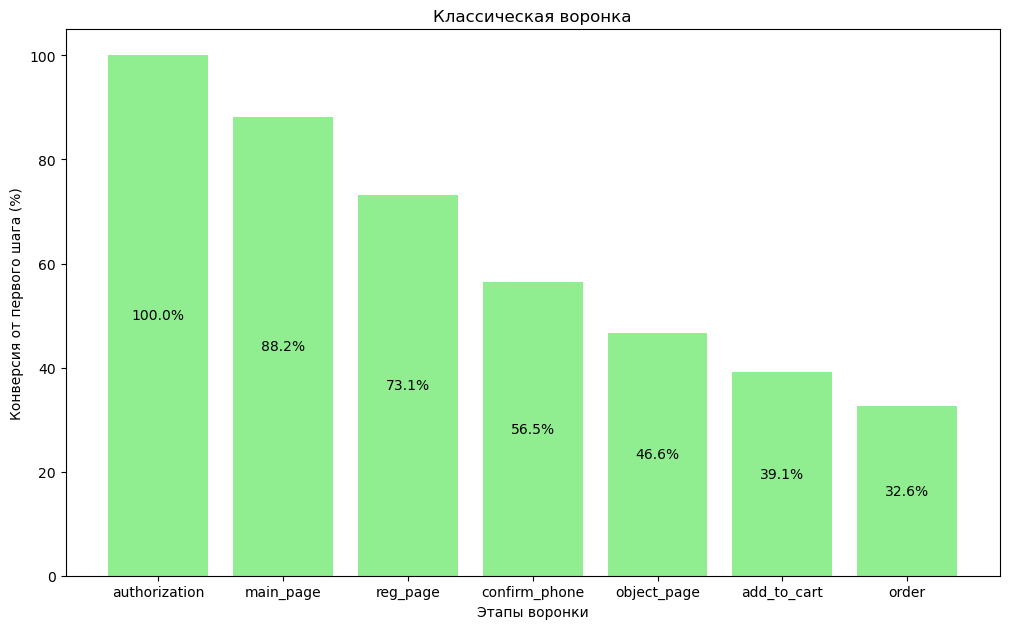

In [7]:
# Построим классическую воронку

# Задаём порядок шагов в воронке
funnel_steps = ['authorization', 'main_page', 'reg_page', 'confirm_phone', 'object_page', 'add_to_cart', 'order']

# Фильтруем датасет, оставляя только нужные шаги воронки (на случай, если в датасете встречаются и прочие действия)
funnel_steps_df = df[df['event'].isin(funnel_steps)]
# Считаем число уникальных пользователей на каждом шаге
funnel_counts = funnel_steps_df.groupby('event')['user_id'].nunique().reindex(funnel_steps).reset_index()

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step': funnel_counts['event'],
   'users': funnel_counts['user_id']
})

# Считаем классическую конверсию
# Сохраним датасет для подсчета классической конверсии отдельно, чтобы не потерять
classic_funnel_df = funnel_df
classic_funnel_df['classic_conversion'] = (classic_funnel_df['users'] / classic_funnel_df['users'].iloc[0] * 100).round(1)
display(funnel_df)

# Визуализируем данные
plt.figure(figsize=(10, 6))
barchart1 = plt.bar(classic_funnel_df['step'], classic_funnel_df['classic_conversion'], color='lightgreen')
for bar in barchart1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height/2,
             f'{height:.1f}%',
             ha='center', va='center',
             fontsize=10,
             color='black')
plt.tight_layout()
plt.title('Классическая воронка')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

,step,users,classic_conversion,step_conversion
0,authorization,7410,100.0,NaN
1,main_page,6537,88.2,88.2
2,reg_page,5417,73.1,82.9
3,confirm_phone,4190,56.5,77.3
4,object_page,3453,46.6,82.4
5,add_to_cart,2899,39.1,84.0
6,order,2416,32.6,83.3


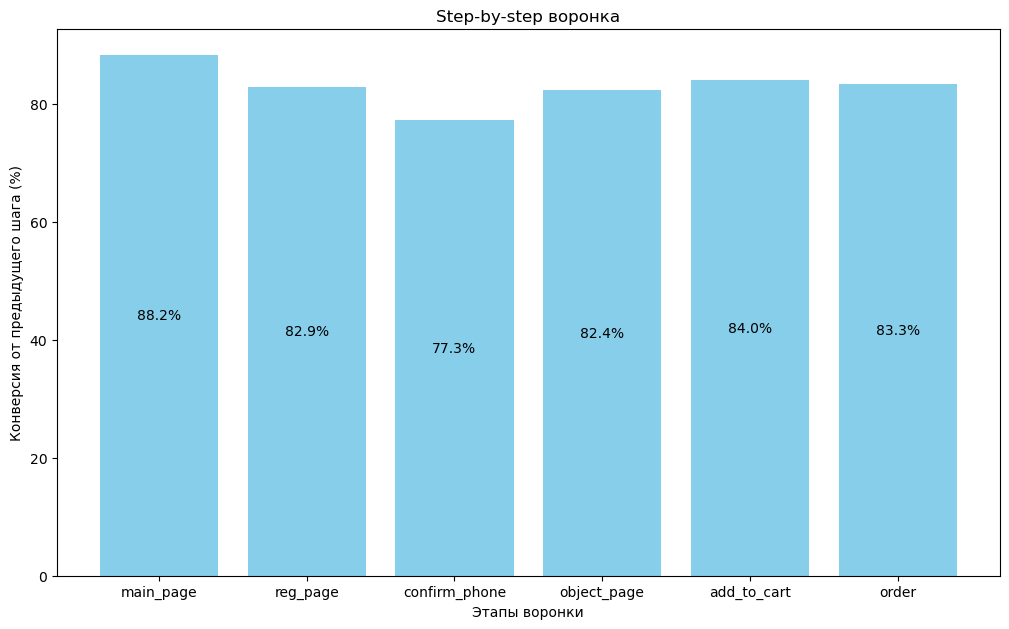

In [8]:
# Считаем step-by-step конверсию
# Создаем отдельный датасет, чтобы не потерять данные
step_funnel_df = funnel_df
step_funnel_df['step_conversion'] = (step_funnel_df['users'] / step_funnel_df['users'].shift(1) * 100).round(1)
display(step_funnel_df)

# Визуализируем данные
plt.figure(figsize=(10, 6))
barchart2 = plt.bar(step_funnel_df['step'][1:], step_funnel_df['step_conversion'][1:], color='skyblue')
for bar in barchart2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height/2,
             f'{height:.1f}%',
             ha='center', va='center',
             fontsize=10,
             color='black')
plt.tight_layout()
plt.title('Step-by-step воронка')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

### Вывод:

Общая воронка выглядит в целом нормально, похоже, что "узких мест" нет:
* Классическая воронка демонстрирует очень плавное снижение конверсии, а итоговая конверсия в заказ достаточно высокая: **32,6%.**
* Step-by-step воронка также демонстрирует высокие значения конверсии на каждом шаге (более 80%). Заметен небольшой "провал" при подтверждении номера телефона: конверсия на этом шаге составляет **77,3%.**  

**Задача 2.2.** Сравнить пользовательский путь в двух приложениях: в мобильной версии и десктопной.

,step,mobile,desktop
0,main_page,83.31,91.05
1,reg_page,88.38,79.35
2,confirm_phone,55.05,90.24
3,object_page,72.52,85.79
4,add_to_cart,86.68,82.91
5,order,85.75,82.34


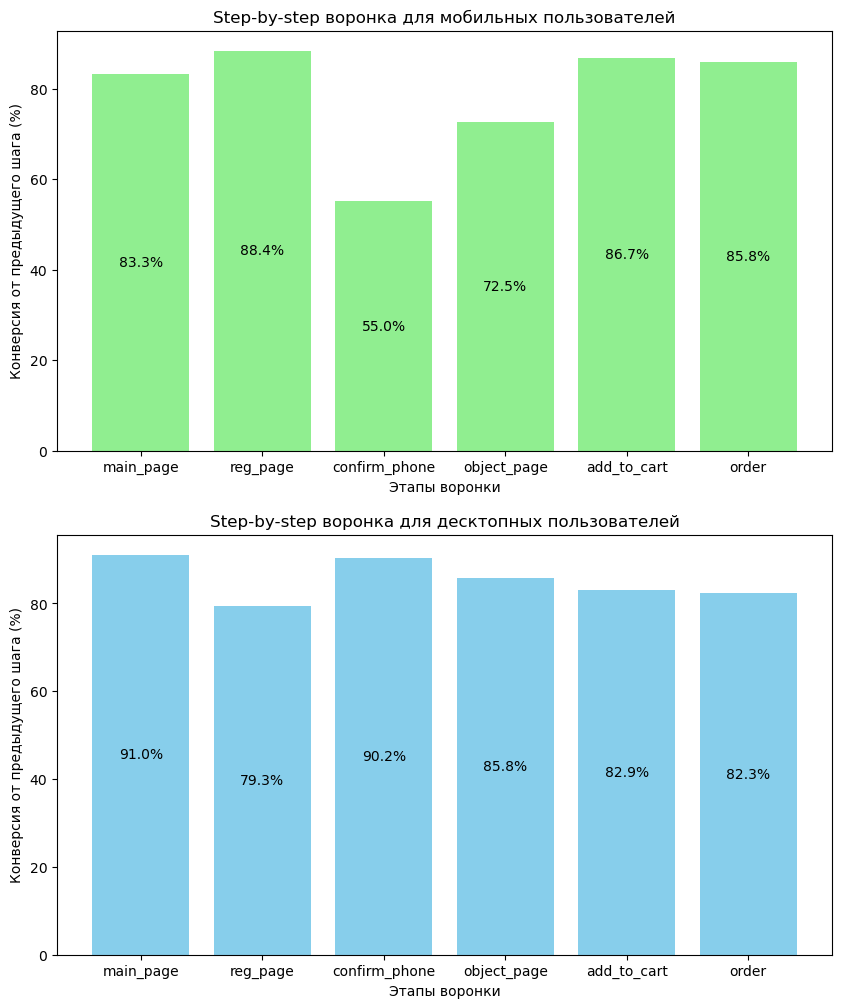

In [9]:
# Создадим отдельные датасеты для разных версий приложения
mobile_df = df[df['device_type'] == 'Mobile']
desktop_df = df[df['device_type'] == 'Desktop']

# Считаем конверсию для мобильной версии приложения
funnel_steps_mobile = mobile_df[mobile_df['event'].isin(funnel_steps)]
funnel_counts_mobile = funnel_steps_mobile.groupby('event')['user_id'].nunique().reindex(funnel_steps).reset_index()
funnel_mobile = (funnel_counts_mobile['user_id'] / funnel_counts_mobile['user_id'].shift(1) * 100).round(2)

# Считаем конверсию для десктопной версии приложения
funnel_steps_desktop = desktop_df[desktop_df['event'].isin(funnel_steps)]
funnel_counts_desktop = funnel_steps_desktop.groupby('event')['user_id'].nunique().reindex(funnel_steps).reset_index()
funnel_desktop = (funnel_counts_desktop['user_id'] / funnel_counts_desktop['user_id'].shift(1) * 100).round(2)

# Соберём через словарь данные в датафрейм и исключим первый шаг для каждого элемента
funnel_compare = pd.DataFrame({
   'step': funnel_steps[1:],
   'mobile': funnel_mobile[1:].values,
   'desktop': funnel_desktop[1:].values
})

display(funnel_compare.head(6))

# Визуализируем получившиеся воронки
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Мобильная версия
barchart3 = axes[0].bar(funnel_compare['step'], funnel_compare['mobile'], color='lightgreen')
for bar in barchart3:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2,
             height/2,
             f'{height:.1f}%',
             ha='center', va='center',
             fontsize=10,
             color='black')
axes[0].set_title('Step-by-step воронка для мобильных пользователей')
axes[0].set_xlabel('Этапы воронки')
axes[0].set_ylabel('Конверсия от предыдущего шага (%)')

# Десктопная версия
barchart4 = axes[1].bar(funnel_compare['step'], funnel_compare['desktop'], color='skyblue')
for bar in barchart4:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2,
             height/2,
             f'{height:.1f}%',
             ha='center', va='center',
             fontsize=10,
             color='black')
axes[1].set_title('Step-by-step воронка для десктопных пользователей')
axes[1].set_xlabel('Этапы воронки')
axes[1].set_ylabel('Конверсия от предыдущего шага (%)')

plt.show()

### Вывод:

При детальном изучении step-by-step воронки в разрезе версий приложения (мобильная и десктопная) заметна проблема среди пользователей, использующих мобильную версию приложения:
* Значительно падает конверсия при переходе к подтверждению номера телефона: на этом этапе продолжают пользоваться лишь 55% пользователей, завершивших регистрацию.
* Также среди мобильных пользователей заметно снижение конверсии при выборе блюд (этап object_page): конверсия на этом шаге составила 72,5%.

Воронка для десктопных пользователей демонстрирует лучшие результаты: на каждом шаге конверсия превышвет 80%, самое низкое значение - на этапе регистрации(79,4%).

Можно предположить, что в мобильной версии приложения плохо работает страница подтверждения номера: например, не на всех устройствах возможно ввести номер телефона или не всегда приходит код/звонок для подтверждения. Необходимо передать данный вопрос разработчикам для проверки корректности работы данной страницы.

Снижение конверсии на этапе выбора блюд может быть связано как с некорректной работой страницы, так и с неудобным дизайном (возможна плохая сомвестимость интерфейса с некоторыми телефонами). Следует подробно изучить проблему с разработчиками и дизайнерами.

## 3. RFM сегментация

**Задача 3.1.** Для каждого покупателя посчитать:
- количество дней с последней покупки — давность (R);
- частоту покупок (F);
- стоимость всех покупок — сумму трат (M).
    
Дата анализа - **03 июля 2021 года**.

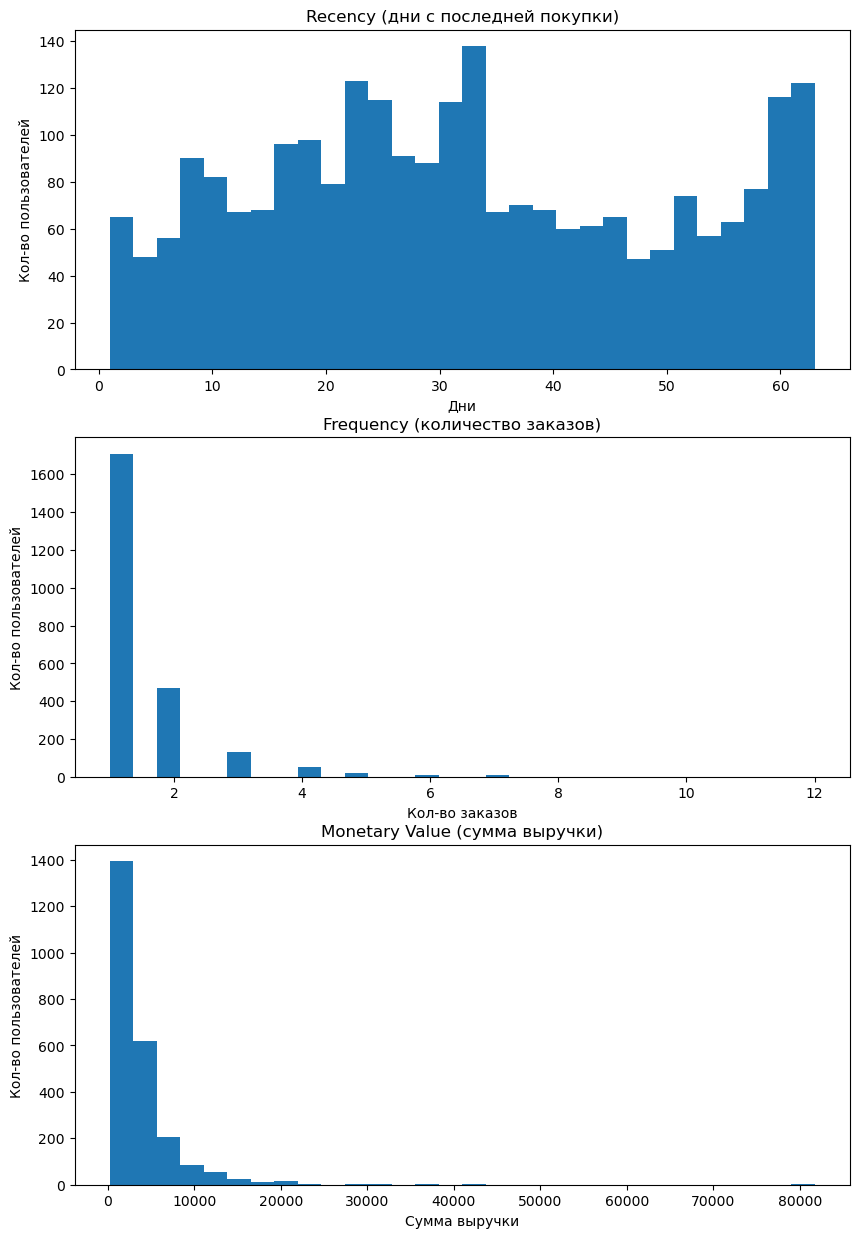

In [10]:
# Фильтруем датасет, оставляем только данные о покупках (завершенных заказах)
orders_df = df[df['event'] == 'order'].copy()
# Считаем количество дней с покупки до анализа
orders_df['datetime'] = pd.to_datetime(orders_df['datetime'])
orders_df['order_recency'] = pd.to_datetime('2021-07-03') - pd.to_datetime(orders_df['datetime'].dt.date)

# Рассчитываем данные для RFM-анализа:
rfm_df = orders_df.groupby('user_id').agg(   
    recency=('order_recency', lambda x: x.min().days),
    frequency=('datetime', 'count'),
    monetary_value=('revenue', 'sum')
).reset_index()

# Визуализируем распределение значений давности, частоты и суммарной выручки с клиента
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Давность
axes[0].hist(rfm_df['recency'], bins=30)
axes[0].set_title('Recency (дни с последней покупки)')
axes[0].set_xlabel('Дни')
axes[0].set_ylabel('Кол-во пользователей')

# Частота
axes[1].hist(rfm_df['frequency'], bins=30)
axes[1].set_title('Frequency (количество заказов)')
axes[1].set_xlabel('Кол-во заказов')
axes[1].set_ylabel('Кол-во пользователей')

# Суммарная выручка
axes[2].hist(rfm_df['monetary_value'], bins=30)
axes[2].set_title('Monetary Value (сумма выручки)')
axes[2].set_xlabel('Сумма выручки')
axes[2].set_ylabel('Кол-во пользователей')

plt.show()

### Вывод:
* **Распределение кол-ва дней с последней покупки**: Данные распределены неравномерно, можно выделить несколько слабых пиков: 20-25 дней (110-120 чел), 30-35 дней (120-140 чел) и 57-63 дня (120-125 чел). Минимальные значения - 5-7 дней и 45-50 дней (50-55 чел). При таком распеределении для выделения сегментов оптимально разбивать данные на равные группы.
*  **Распределение кол-ва заказов**: Наблюдается сильное правостороннее смещение: большая часть пользователей сделала лишь один заказ. Для выделения сегментов можно разбить данные по перцентилям или задать границы групп вручную (т.к. данные цельночисленные).
*  **Распределение суммы выручки с клиента**: Распределение сильно смещено вправо: пользователи в основном делают маленькие недорогие заказы. Для сегментации можно задать границы групп вручную (если, например, существуют конкретные требования от бизнеса) или разделить данные по перцентилям для получения оптимальных сегментов.

**Задача 3.2.** Выделите **RFM-сегменты** и изучите распределение пользователей по ним.
    
Примените следующие подходы к выделению RFM сегментов:
- **Recency** — разделите на три равные группы.
- **Frequency** —  разделите на три группы: 
    - пользователи с 1 заказом (F-сегмент с небольшим количеством заказов);
    - пользователи с 2 заказами (F-сегмент со средним количеством заказов);
    - пользователи с 3 и более заказами (F-сегмент с большим количеством заказов).
- **Monetary** — разделите на три группы по 33-му и 66-му перцентилям.
    
После этого посчитайте количество покупателей в каждом сегменте, сделайте промежуточные выводы и напишите рекомендации.

In [11]:
# Определяем группу пользователя по recency (делим на 3 равные группы) 
rfm_df['r'] = pd.cut(rfm_df['recency'], bins=3, labels=[3,2,1])

# Определяем группу пользователя по frequency (делим по группам по кол-ву заказов): 
rfm_df['f'] = pd.cut(rfm_df['frequency'], [0,1,2,15], labels=[1,2,3], include_lowest=True)

# Определяем группу пользователя по monetary value (делим по 33 и 66 перцентилям): 
rfm_df['m'] = pd.qcut(rfm_df['monetary_value'], q=3, labels=[1,2,3])

# Находим групповой RFM-индекс:
rfm_df[['r','f','m']] = rfm_df[['r','f','m']].astype('str')
rfm_df['rfm_group'] = rfm_df['r'] + rfm_df['f'] + rfm_df['m']

# Группируем данные по сегментам, считаем кол-во и долю пользователей:
rfm_segments = rfm_df.groupby('rfm_group').agg({'user_id':'nunique'}).reset_index()
rfm_segments['user_share'] = round(rfm_segments['user_id'] / rfm_segments['user_id'].sum() * 100, 2)

display(rfm_segments.sort_values(by='user_id', ascending=False))

,rfm_group,user_id,user_share
8,211,281,11.63
0,111,247,10.22
17,311,246,10.18
9,212,237,9.81
1,112,216,8.94
18,312,186,7.70
10,213,122,5.05
13,223,115,4.76
16,233,102,4.22
19,313,99,4.10


### Вывод:
* Нелояльная аудитория: 111, 211, 311, 212, 112, 121, 122, 113 (59,36%): Такие клиенты воспользовались сервисом в основном однократно и/или сделавшие небольшие заказы. С такими клиентами работать нецелесообразно, т.к. их привлечение маловероятно, а потенциальное влияние на выручку низкое. Такие клиенты составляют основную долю от всех пользователей платформы.
* Самые лояльные клиенты: 333, 323, 313, 332, 233, 223, 232 (20,11%): Такие клиенты относительно часто делают заказы со средним/высоким чеком, также относительно часто возвращаются в приложение для повторного заказа. Таких клиентов следует удерживать при помощи специализированных предложений, а также мотивировать их делать заказы чаще. Таких клиентов всего 20%,но при этом они могут генерировать значительную долю выручки компании.
* Новые платежеспособные пользователи: 312, 213 (11,8%): Пользователи, которые недавно однократно совершили заказ на сумму среднюю/выше среднего. Таких клиентов следует мотивировать к повторным заказам, т.к. у таких клиентов есть потенциал стать постоянными.
* Ушедшие платежеспособные клиенты: 123, 133, 132 (5,55%): Клиенты, ранее активно пользовавшиеся сервисом и приносившие высокую выручку. Таким клиентам следует разослать индивидуальные предложения, мотивирующие вернуться и далее использовать приложение.
* Активные клиенты с низким чеком: 321, 221, 231, 222 (3,18%): Клиенты, которые относительно часто совершают заказы через приложение на небольшие суммы. Таким клиентам стоит делать предложения, способствующие повышению среднего чека.

## 4. K-Means кластеризация

**Задача 4.1.** Подготовить данные для кластеризации и для каждого ресторана подсчитать:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

In [12]:
# Рассчитаем все индикаторы для каждого ресторана, используем датасет orders_df, содержащий только завершенные заказы
clusters_df = orders_df.groupby('rest_id').agg(   
    total_orders=('order_id', 'nunique'),
    avg_order_price=('revenue', 'mean'),
    unique_dishes=('object_id', 'nunique')
).reset_index()

display(clusters_df)

,rest_id,total_orders,avg_order_price,unique_dishes
0,1be5a933aab34fbab594bebba48e976e,144,2260.180222,28
1,1d6bb74687104fa1953924c9684fe624,108,2959.256481,19
2,2c6095730b514c189ee41c65f03febc3,8,1673.000000,4
3,3247a3b5f9494812a3c1a73c5b61f004,33,2777.209697,4
4,39b7eab4f4704ed2886fafe171489960,33,2011.269697,5
5,43e40bacafe8409bb5592877a42d737e,43,3313.064186,6
6,4a693ca500b44ba499f92a724aec5f17,107,2989.588785,12
7,4b9cde3378c447ed81c2c6d4854d4f7e,7,2544.000000,5
8,55d4027ac83e438f9f893892f6903409,1001,2674.652364,75
9,55d6470712ee48e98509478ad6aa18ee,5,4754.400000,2


**Задача 4.2.** Найти оптимальное количество кластеров

In [13]:
# Удаляем из полученного в прошлой задаче датасета столбец с названиями ресторанов
clusters_df = clusters_df.drop(columns='rest_id')

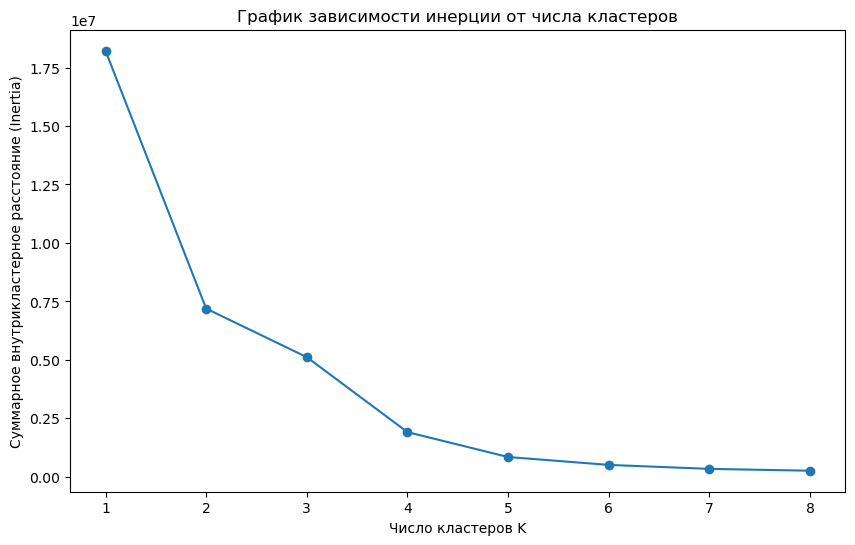

In [14]:
# Создаём массив для хранения значений inertia для разбиения с разным кол-вом кластеров
i = []

# Задаём диапазон кол-ва кластеров
min_k = 1
max_k = 8

plt.figure(figsize=(10, 6))

# Перебираем разное количество кластеров
for k in range(min_k, max_k + 1):
    km = KMeans(n_clusters=k, random_state=1)
    km.fit_transform(clusters_df)
    i.append(km.inertia_)

# Строим график зависимости инерции от количества кластеров
plt.plot(range(min_k, max_k + 1), i, marker='o')
plt.xlabel('Число кластеров K')
plt.ylabel('Суммарное внутрикластерное расстояние (Inertia)')
plt.title('График зависимости инерции от числа кластеров')
plt.show()

### Вывод:

Согласно графику, резкое снижение суммарного внутрикластерного расстояния отмечается после точки 4 на оси Х, таким образом, **оптимальное количество кластеров - 4.**

**Задача 4.3.** Провести кластеризацию, проанализировать полученные результаты и рассчитать средние значения по каждому кластеру.
    
Визуализировать результаты, чтобы проследить зависимость признаков друг от друга:
- средний чек в зависимости от количества заказов;
- количество блюд в зависимости от количества заказов.

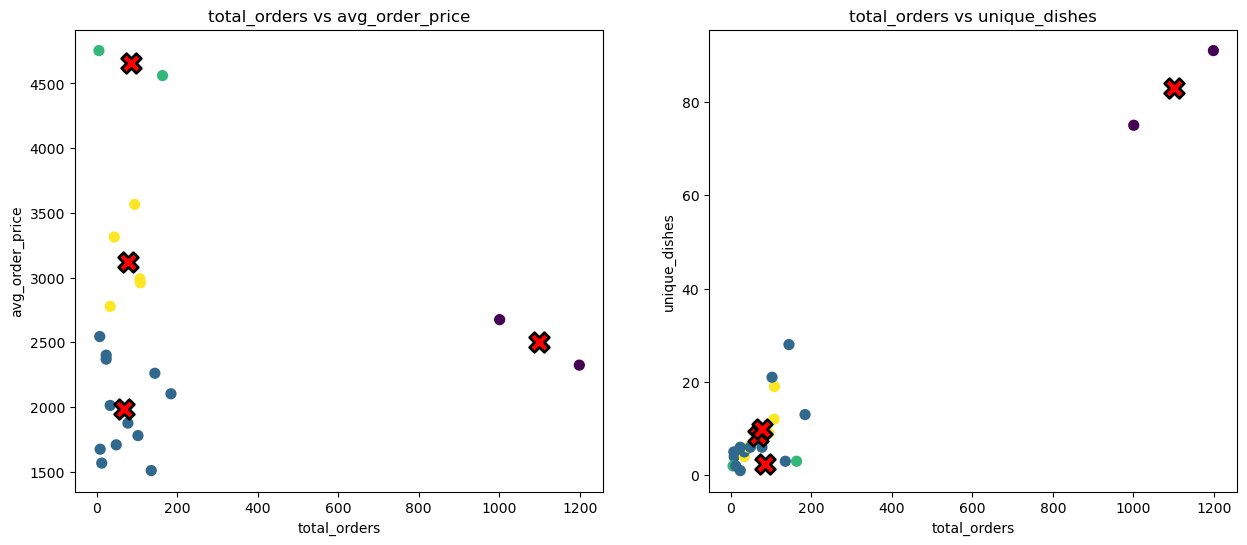

In [15]:
# Проведем кластеризацию и визуализируем результаты

# Указываем кол-во кластеров 
kmeans = KMeans(n_clusters=4, random_state=1)
labels = kmeans.fit_predict(clusters_df)

# Считаем координаты центроидов
centroids = kmeans.cluster_centers_

# Строим 2 графика
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Указываем писок названий признаков для графиков
axs = ["total_orders", "avg_order_price", "unique_dishes"]

# Указываем пары признаков согласно заданию:
for i, (x_idx, y_idx) in enumerate([[0, 1], [0, 2]]):
   x_label, y_label = axs[x_idx], axs[y_idx]

   # Наносим на график точки
   axes[i].scatter(
       clusters_df[x_label],
       clusters_df[y_label],
       c=labels,
       cmap='viridis',
       s=50
   )

   # Наносим на график центроиды кластеров
   axes[i].scatter(
       centroids[:, x_idx],
       centroids[:, y_idx],
       s=200,
       c='red',
       edgecolors='black',
       linewidths=2,
       marker='X'
   )

   # Подписи осей и заголовок графика
   axes[i].set_xlabel(x_label)
   axes[i].set_ylabel(y_label)
   axes[i].set_title(f'{x_label} vs {y_label}')

# Показываем итоговый набор визуализаций
plt.show()

### Вывод:

При помощи алгоритма K-Means рестораны были разделены на 4 кластера:

1. **Первый кластер:** рестораны с ценами сильно выше среднего (4500 руб. и выше) и небольшим ассортиментом (5 - 7 блюд), количество заказов низкое (менее 200). Всего таких ресторана два. С наибольшей вероятностью это заведения премиум-класса, которые привлекают мало клиентов, но генерируют наиболее высокую выручку.
2.  **Второй кластер:** рестораны в среднем ценовом диапазоне (2800 - 3600 руб.) с относительно небольшим ассортиментом (5 - 20 блюд), количество заказов очень низкое (до 100). Вероятно, в данный кластер попали небольшие рестораны средними по рынку ценами.
3.  **Третий кластер:** рестораны с ценами ниже среднего (1500 - 2600 руб.) с относительно небольшим ассортиментом (до 30 блюд, в основном - 5 - 10), количество заказов низкое (до 200). Таких ресторанов больше всего. Скорее всего, это небольшие новые рестораны, установившие цены ниже среднего по рынку для привлечения клиентов или просто рестораны эконом-класса. 
4.  **Четвертый кластер:** рестораны с ценами немного ниже среднего (2300 - 2700 руб.) и широким ассортиментом (70 - 90 блюд), количество заказов очень высокое (более 1000). Таких ресторанов всего два. Вероятнее всего, крупные сетевые рестораны, на которые приходится основная доля спроса.

## 5. Итоговый вывод и рекомендации

### 1. Слабые места в продуктовой воронке

**Общая воронка** демонстрирует стабильно **высокие показатели конверсии** на каждом шаге: конверсия в заказ составляет 32,6%. В step-by-step воронке на каждом шаге конверсия превышает 80% за исключением этапа подтверждения номера телефона (конверсия - 79,4%).

Явные проблемы наблюдаются **среди мобильных пользователей**: 
* Значительно **падает конверсия при переходе к подтверждению номера телефона**: на этом этапе продолжают пользоваться приложением лишь **55%** пользователей, завершивших регистрацию. Можно предположить сбои в работе страницы подтверждения номера: например, не на всех устройствах возможно ввести номер телефона или не всегда приходит код/звонок для подтверждения. Рекомендуется передать данный вопрос разработчикам для проверки корректности работы данной страницы.
* Также заметно **снижение конверсии при выборе блюд** (этап object_page): конверсия на этом шаге составила **72,5%**. Снижение конверсии на этапе выбора блюд может быть связано как с некорректной работой страницы, так и с неудобным дизайном (возможна плохая сомвестимость интерфейса с некоторыми телефонами). Рекомендуется подробно изучить проблему с разработчиками и дизайнерами.

**Воронка для десктопных пользователей демонстрирует лучшие результаты**: на каждом шаге конверсия превышвет **80%**, самое низкое значение - на этапе регистрации (79,4%).

### 2. RFM-сегментация для определения ключевых категорий клиентов

Произведена сегментация пользователей на различные поведенческие сегменты с помощью RFM-сегментации по трём показателям:
* Давность (Recency)
* Частота покупок (Frequency)
* Сумма трат (Monetary),
где для кажого показателя минимальный балл - 1, максимальный - 3.

**Результаты:**

### Вывод:
* **Нелояльная аудитория: 111, 211, 311, 212, 112, 121, 122, 113 (59,36%):** Такие клиенты воспользовались сервисом в основном однократно и/или совершили небольшие заказы. С такими клиентами работать нецелесообразно, т.к. их привлечение маловероятно, а потенциальное влияние на выручку низкое. Такие клиенты составляют основную долю от всех пользователей платформы. Рекомендуется дополнительно изучить работу каналов привлечения: вероятно, большинство нелояльных пользователей приходят через определенные каналы.
* **Самые лояльные клиенты: 333, 323, 313, 332, 233, 223, 232 (20,11%):** Такие клиенты относительно часто делают заказы со средним/высоким чеком, также относительно часто возвращаются в приложение для повторного заказа. Таких клиентов следует удерживать при помощи специализированных предложений, а также мотивировать их делать заказы чаще. Таких клиентов всего 20%,но при этом они могут генерировать значительную долю выручки компании.
* **Новые платежеспособные пользователи: 312, 213 (11,8%):** Пользователи, которые недавно однократно совершили заказ на сумму среднюю/выше среднего. Таких клиентов следует мотивировать к повторным заказам, т.к. у таких клиентов есть потенциал стать постоянными.
* **Ушедшие платежеспособные клиенты: 123, 133, 132 (5,55%)**: Клиенты, ранее активно пользовавшиеся сервисом и приносившие высокую выручку. Таким клиентам следует разослать индивидуальные предложения, мотивирующие вернуться и далее использовать приложение.
* **Активные клиенты с низким чеком: 321, 221, 231, 222 (3,18%):** Клиенты, которые относительно часто совершают заказы через приложение на небольшие суммы. Таким клиентам стоит делать предложения, способствующие повышению среднего чека.

### 2. K-Means кластеризация ресторанов-партнеров

Было выделено оптимальное количество кластеров - **4**.

Все рестораны-партнеры (21 шт.) были разделены на следующие **4 сегмента**, также предоставлены рекомендации по улучшению взаимодействия с ними:

1. **Заведения премиум класса**: рестораны с ценами сильно выше среднего (4500 руб. и выше) и небольшим ассортиментом (5 - 7 блюд), количество заказов низкое (менее 200). Всего таких ресторана два. Такие рестораны **привлекают мало клиентов**, но **генерируют наиболее высокую выручку**.

    **Рекомендации по улучшению взаимодействия**:
* Выделение на платформе отдельного VIP-сегмента для данных заведений
* Отдельно выделенная группа обученных курьеров для повышения качества сервиса
* Дополнительные возможности на платформе: возможность загрузки на платформу фото и видео, сториз и пр.
   
2. **Небольшие рестораны в среднем ценовом дианазоне**: рестораны в среднем ценовом диапазоне (2800 - 3600 руб.) с относительно небольшим ассортиментом (5 - 20 блюд), количество заказов очень низкое (до 100).

    **Рекомендации по улучшению взаимодействия**:
* Промо-акции для ресторанов: например, пониженная комиссия или ее отсутствие в первый месяц сотрудничества
* Стимуляция спроса на продукцию ресторана путем предоставления акций за счет заведения (скидки в часы с минимальной активностью, повышенный кэшбек для пользователей и пр.)

3. **Новые рестораны/эконом класс**: рестораны с ценами ниже среднего (1500 - 2600 руб.) с относительно небольшим ассортиментом (до 30 блюд, в основном - 5 - 10), количество заказов низкое (до 200). Таких ресторанов больше всего. Скорее всего, это **небольшие новые рестораны, установившие цены ниже среднего по рынку для привлечения клиентов** или просто **рестораны эконом класса**.

    **Рекомендации по улучшению взаимодействия**:
* Промо-акции для ресторанов: например, пониженная комиссия или ее отсутствие в первый месяц сотрудничества
* Предоставление полезных образовательных материалов для рестораторов

4. **Крупные сетевые рестораны**: рестораны с ценами немного ниже среднего (2300 - 2700 руб.) и широким ассортиментом (70 - 90 блюд), количество заказов очень высокое (более 1000). Всего два ресторана попали в данную категорию. На эти рестораны приходится основная доля спроса.

    **Рекомендации по улучшению взаимодействия**:
* Индивидуальная команда поддержки для быстрого реагирования в случае возникновения проблем
* Предоставление аналитических материалов по результатам работы сети
* Программа лояльности: чем больше заказов, тем ниже комиссия.